# Individual homework project 2

Leda Gale 

You will apply statistical testing and correlation analysis to the ShopNow dataset.

For each question:

1. Run the appropriate test.
2. Report the test statistic and p-value (if applicable).
3. Interpret the result in plain English.
4. Explain what it means for the business.

In [4]:
# Import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")
from scipy.stats import ttest_ind, chi2_contingency, pearsonr
import os

In [6]:
print(os.getcwd())
print(os.listdir())

/home/leda/Projects/Mayerfeld_Hw2
['marketing_campaigns.csv', 'hw_2_project (1).ipynb:Zone.Identifier', 'web_sessions.csv', '.git', 'customers.csv', '.ipynb_checkpoints', 'transactions.csv', 'hw_2_project (1).ipynb']


In [7]:
# Import datasets
customers = pd.read_csv("customers.csv")
transactions =  pd.read_csv("transactions.csv")
sessions = pd.read_csv("web_sessions.csv")
campaigns = pd.read_csv("marketing_campaigns.csv")

### Specific questions

Q1. Do customers from the UK spend more per transaction than customers from Germany?

H0 (Null Hypothesis): There is no significant difference between the mean transaction spend of UK customers and Germany custoners.

H1 (Alternative Hypothesis): There is a significant difference between the mean transaction spend of UK customers and Germany custoners.

In [8]:
customers.head()

,customer_id,age,gender,country,acquisition_channel,signup_date
0,1,56.0,Other,Germany,referral,2019-07-21
1,2,38.0,Other,Netherlands,email,2022-03-04
2,3,28.0,Other,Australia,referral,2024-05-21
3,4,19.0,Female,Australia,paid_search,2022-06-28
4,5,38.0,Female,Australia,referral,2024-07-17


In [15]:
# Merging the dataset to link transactions with country information 
# Common key "customer_id"
customers_transactions = pd.merge(transactions,customers, on = "customer_id", how = "left")

In [53]:
# Preparing the datasets per country
uk_customers = customers_transactions[customers_transactions["country"] == "UK"]["purchase_value"]
germany_customers = customers_transactions[customers_transactions["country"] == "Germany"]["purchase_value"]

# Getting a brief descriptive statistics
print(f'---- Descriptive Statistics ---')
print(f'UK Average Spend: {uk_customers.mean():.2f}')
print(f'Germany Average Spend: {germany_customers.mean():.2f}')
print(f"Difference: {abs(uk_customers.mean() - germany_customers.mean()):.2f}")

# Statisticar test (T-test)
t_stat, p_value = ttest_ind(uk_customers, germany_customers, equal_var = False)

print(f'\n---- Statistical test ---')
print(f't-statistic: {t_stat:.3f}')
print(f'p-value: {p_value:.5f}')

# Interpretation 
alpha = 0.05
if p_value < alpha:
    print("Conclusion: Reject the Null Hypothesis (Statistically Significant difference found.)")
else:
    print("Conclusion: Fail to Reject the Null Hypothesis (No statistically significant difference found.)")

---- Descriptive Statistics ---
UK Average Spend: 75.63
Germany Average Spend: 75.76
Difference: 0.13

---- Statistical test ---
t-statistic: -0.112
p-value: 0.91082
Conclusion: Fail to Reject the Null Hypothesis (No statistically significant difference found.)


To determine if UK customers spend more per transaction than German customers, an independent t-test was conducted. The null Hypothesis for this case assumed there was no difference in the mean spent between the two groups. A p-value of 0.91 is greater than the significance threshold of 0.05; the test fails to reject the null hypothesis. In conclusion, it was observed that the difference in spending is not statistically significant.

NOTE: Because the number of transactions and the variance (spread) of spending might be different in both countries, the Welch’s T-test was used by setting equal_var=False.

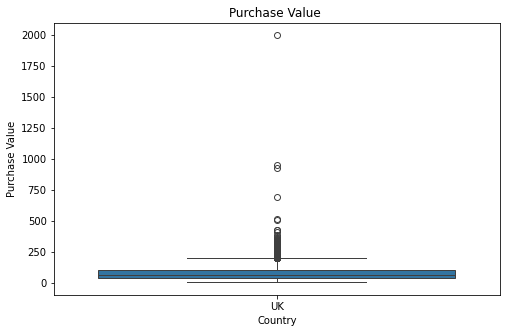

In [45]:
plt.figure(figsize=(8,5))
sns.boxplot(x="country", y="purchase_value", 
            data= customers_transactions[customers_transactions["country"] == "UK"])

plt.title("Purchase Value ")
plt.xlabel("Country")
plt.ylabel("Purchase Value")

plt.show()

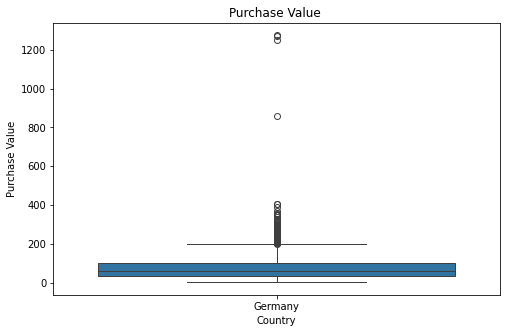

In [46]:
plt.figure(figsize=(8,5))
sns.boxplot(x="country", y="purchase_value", 
            data= customers_transactions[customers_transactions["country"] == "Germany"])

plt.title("Purchase Value ")
plt.xlabel("Country")
plt.ylabel("Purchase Value")

plt.show()

Q2. Do discounted purchases differ in average value from non-discounted purchases?

H0 (Null Hypothesis): There is no significant difference between the mean of discounted purchases and non - discounted purchases.

H1 (Alternative Hypothesis): There is significant difference between the mean of discounted purchases and non - discounted purchases.

In [26]:
transactions.head()

,transaction_id,customer_id,product_category,purchase_value,discount_used,purchase_date
0,1,8141,home,74.32,0,2023-09-05
1,2,1297,fashion,17.51,0,2019-08-07
2,3,7930,toys,39.96,1,2020-02-07
3,4,2426,electronics,43.79,0,2020-10-02
4,5,6614,fashion,187.01,0,2023-09-15


In [65]:
# Preparing the datasets 
discounted_purchases = transactions[transactions["discount_used"] == 1]["purchase_value"]
nondiscounted_purchases = transactions[transactions["discount_used"] == 0]["purchase_value"]

# Getting a brief descriptive statistics
print(f'---- Descriptive Statistics ---')
print(f'Discounted Purchases: {discounted_purchases.mean():.2f}')
print(f'Non-Discounted Purchases:  {nondiscounted_purchases.mean():.2f}')
print(f"Difference: {abs(discounted_purchases.mean() - nondiscounted_purchases.mean()):.2f}")

# Statisticar test (T-test)
t_stat, p_value = ttest_ind(discounted_purchases, nondiscounted_purchases, equal_var = False)

print(f'\n---- Statistical test ---')
print(f't-statistic: {t_stat:.3f}')
print(f'p-value: {p_value:.200f}')

# Interpretation 
alpha = 0.05
if p_value < alpha:
    print("Conclusion: Reject the Null Hypothesis (Statistically Significant difference found.)")
else:
    print("Conclusion: Fail to Reject the Null Hypothesis (No statistically significant difference found.)")

---- Descriptive Statistics ---
Discounted Purchases: 64.40
Non-Discounted Purchases:  80.76
Difference: 16.37

---- Statistical test ---
t-statistic: -29.982
p-value: 0.00000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000761119
Conclusion: Reject the Null Hypothesis (Statistically Significant difference found.)


To determine if discounted purchases differ in average value from non-discounted purchases, an independent t-test was conducted. The null Hypothesis assumed there was no difference in the mean purchase value between the two transactions. The analysis showed a difference of 16.37 in the mean of both purchases The p-value in this case is significantly lower than the threshold of 0.05. The test rejects the null hypothesis, as it was observed that the difference in spending is statistically significant.

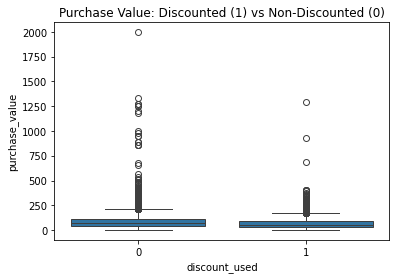

In [54]:
# Quick code to visualize the difference
sns.boxplot(x='discount_used', y='purchase_value', data=transactions)
plt.title('Purchase Value: Discounted (1) vs Non-Discounted (0)')
plt.show()

Q3. Do male and female customers differ in average purchase value?

Q4. Do customers acquired via email spend more than those from social channels?

Q5. Is device type associated with conversion?

Q6. Is acquisition channel associated with conversion?

Q7. Is product category associated with discount usage?

Q8. Is time on site correlated with purchase value?

Q9. Is number of pages viewed correlated with purchase value?

Q10. Is time on site correlated with pages viewed?

### Challenges

C1. Explore whether high-spending customers behave differently in terms of session time.

Define “high spending” yourself.

C2. Find a relationship (difference or correlation) that you believe is meaningful for business strategy.

Explain why.

c3. Identify a statistically significant result that may not be practically meaningful.

Explain why statistical significance ≠ business importance.